In [1]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Self-Made vs. Inherited Wealth in Billionaires
What features are most likely indicate that a billionaire has inherited their wealth?

In [2]:
wealth_data = pd.read_csv(filepath_or_buffer='/kaggle/input/datasets/nelgiriyewithana/billionaires-statistics-dataset/Billionaires Statistics Dataset.csv')

def set_top_n_cat_for_feature(feature_name, data=wealth_data):
    top_n_index = wealth_data[feature_name].value_counts().nlargest(20).index
    wealth_data[feature_name] = wealth_data[feature_name].where(wealth_data[feature_name].isin(top_n_index), 'Other')

In [3]:
wealth_data.finalWorth = wealth_data.finalWorth * 1000 # finalWorth in billions
wealth_data['gdp_country'] = wealth_data['gdp_country'].str.replace('$','').replace(',','', regex=True).astype(float)

wealth_data['numSources'] = wealth_data.source.apply(lambda s: len(s.split(",")))
wealth_data['isExpat'] = (wealth_data.country != wealth_data.countryOfCitizenship)

set_top_n_cat_for_feature("city")
set_top_n_cat_for_feature("country")
set_top_n_cat_for_feature("countryOfCitizenship")

# Remove redundant or unimportant columns
drop_columns = ['firstName', 'lastName', 'personName', 'birthDate', 'date', 'title', 'birthYear', 'birthMonth', 'birthDay',
                 'state', 'residenceStateRegion', 'status', 'source', 'category', 'source', 'organization',
                 'latitude_country', 'longitude_country']

wealth_df = wealth_data.drop(drop_columns, axis=1)

# wealth_df.head(50)

In [4]:
print("\n", "Number of Billionaires (2023): ", len(wealth_df))

billionaires_by_country = wealth_df.groupby(['country'])['country'].count()
print("\n", "All Features: ", "\n", wealth_df.columns.values)


 Number of Billionaires (2023):  2640

 All Features:  
 ['rank' 'finalWorth' 'age' 'country' 'city' 'industries'
 'countryOfCitizenship' 'selfMade' 'gender' 'cpi_country'
 'cpi_change_country' 'gdp_country' 'gross_tertiary_education_enrollment'
 'gross_primary_education_enrollment_country' 'life_expectancy_country'
 'tax_revenue_country_country' 'total_tax_rate_country'
 'population_country' 'numSources' 'isExpat']


In [5]:
print("Numerical Data Summary: ")
wealth_df.describe(include=np.number, percentiles=[]).T

Numerical Data Summary: 


,count,mean,std,min,50%,max
rank,2640.0,1.289159e+03,7.396937e+02,1.000000e+00,1.312000e+03,2.540000e+03
finalWorth,2640.0,4.623788e+06,9.834241e+06,1.000000e+06,2.300000e+06,2.110000e+08
age,2575.0,6.514019e+01,1.325810e+01,1.800000e+01,6.500000e+01,1.010000e+02
cpi_country,2456.0,1.277552e+02,2.645295e+01,9.955000e+01,1.172400e+02,2.885700e+02
cpi_change_country,2456.0,4.364169e+00,3.623763e+00,-1.900000e+00,2.900000e+00,5.350000e+01
gdp_country,2476.0,1.158287e+13,9.575588e+12,3.154058e+09,1.991000e+13,2.142770e+13
gross_tertiary_education_enrollment,2458.0,6.722567e+01,2.134343e+01,4.000000e+00,6.560000e+01,1.366000e+02
gross_primary_education_enrollment_country,2459.0,1.028585e+02,4.710977e+00,8.470000e+01,1.018000e+02,1.421000e+02
life_expectancy_country,2458.0,7.812282e+01,3.730099e+00,5.430000e+01,7.850000e+01,8.420000e+01
tax_revenue_country_country,2457.0,1.254624e+01,5.368625e+00,1.000000e-01,9.600000e+00,3.720000e+01


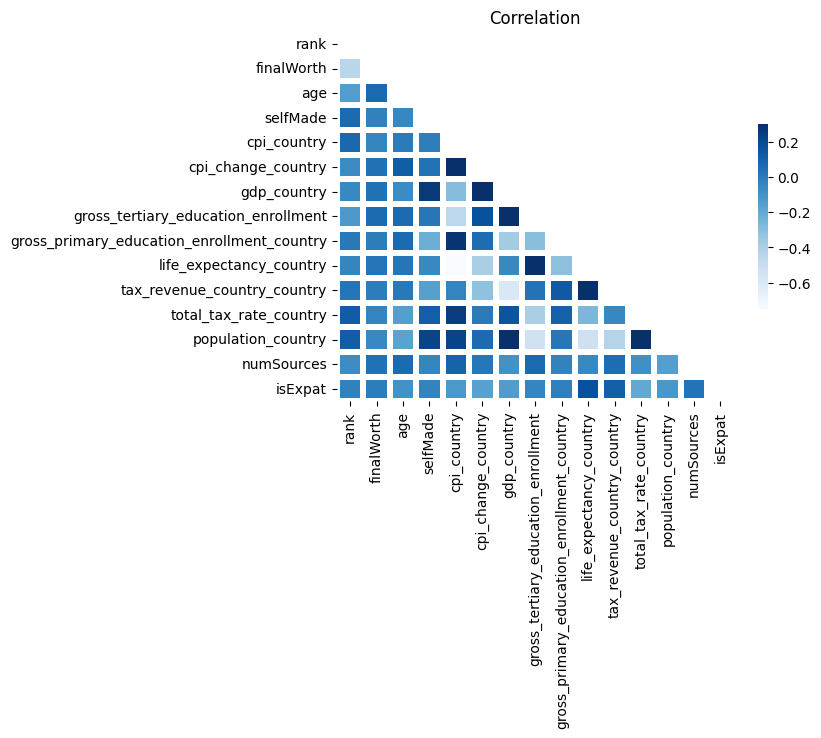

In [6]:
corr = wealth_df.corr(numeric_only=True)
sns.heatmap(corr, mask=np.triu(corr), vmax=.3, linewidths=3, cmap='Blues', cbar_kws={"shrink": .5})
plt.title("Correlation")
plt.show()

In [7]:
print("Categorical Data Summary: ")
wealth_df.describe(include='O').T

Categorical Data Summary: 


,count,unique,top,freq
country,2640,21,United States,754
city,2640,21,Other,1740
industries,2640,18,Finance & Investments,372
countryOfCitizenship,2640,21,United States,735
gender,2640,2,M,2303


In [8]:
print("Top 20 Countries with billionaires:")
print(wealth_df.groupby('country').country.count().sort_values(ascending=False)[1:].index.values)

print("\nTop 20 Cities with billionaires:")
print(np.delete(wealth_df.groupby('city').city.count().sort_values(ascending=False)[1:].index.values,1))

Top 20 Countries with billionaires:
['China' 'Other' 'India' 'Germany' 'United Kingdom' 'Russia' 'Switzerland'
 'Hong Kong' 'Italy' 'Singapore' 'Brazil' 'Taiwan' 'Australia' 'Canada'
 'Japan' 'France' 'South Korea' 'Thailand' 'Sweden' 'Israel']

Top 20 Cities with billionaires:
['New York' 'Beijing' 'Shanghai' 'London' 'Moscow' 'Mumbai' 'Shenzhen'
 'Singapore' 'Delhi' 'San Francisco' 'Hangzhou' 'Los Angeles' 'Taipei'
 'Bangkok' 'Guangzhou' 'Seoul' 'Milan' 'Tokyo' 'Istanbul']


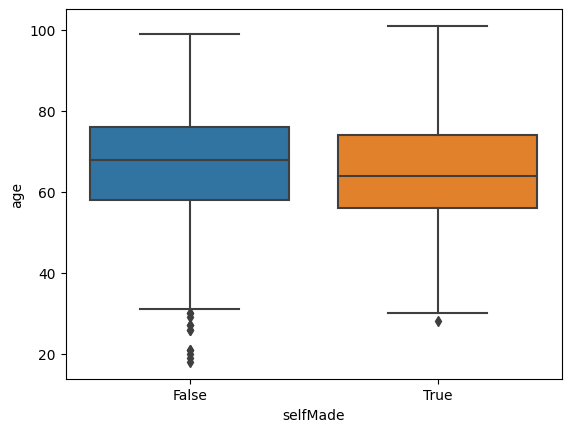

In [9]:
sns.boxplot(wealth_df, x='selfMade', y='age')
plt.show()

In [10]:
self_made_percentage = wealth_df.groupby(by="selfMade").count() / wealth_df.shape[0]

print("Target Feature: 'selfMade'\n")
print("Inherited: ", (self_made_percentage.iloc[0][0]*100).round(2), "%")
print("Self Made: ", (self_made_percentage.iloc[1][0]*100).round(2), "%")

Target Feature: 'selfMade'

Inherited:  31.36 %
Self Made:  68.64 %


In [11]:
print("Numerical Features:")
numerical_features = wealth_df.describe(include=np.number).columns.values
print(numerical_features)

print("\n", "Categorical Features:")
categorical_features = wealth_df.describe(include=['O']).columns.values
print(categorical_features)

Numerical Features:
['rank' 'finalWorth' 'age' 'cpi_country' 'cpi_change_country'
 'gdp_country' 'gross_tertiary_education_enrollment'
 'gross_primary_education_enrollment_country' 'life_expectancy_country'
 'tax_revenue_country_country' 'total_tax_rate_country'
 'population_country' 'numSources']

 Categorical Features:
['country' 'city' 'industries' 'countryOfCitizenship' 'gender']


In [12]:
nan_count = wealth_df.isna().sum()
nan_count = nan_count[nan_count > 0]
print(nan_count.sort_values(ascending=False))

cpi_country                                   184
cpi_change_country                            184
tax_revenue_country_country                   183
gross_tertiary_education_enrollment           182
life_expectancy_country                       182
total_tax_rate_country                        182
gross_primary_education_enrollment_country    181
gdp_country                                   164
population_country                            164
age                                            65
dtype: int64


In [13]:
for col in nan_count.index:
    if col == 'age':
        wealth_df[col] = wealth_df[col].fillna(wealth_df[col].median())
    else:
        wealth_df[col] = wealth_df.groupby('country')[col].transform(lambda x: x.fillna(x.median()))
        wealth_df[col] = wealth_df[col].fillna(wealth_df[col].median())
        
print("Remaining Null Values: ", wealth_df.isnull().sum().sum())

Remaining Null Values:  0


In [14]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

x = wealth_df.drop(columns=["selfMade"])
y = wealth_df.selfMade

# Normalize/scale data
transformer = make_column_transformer(
    (StandardScaler(), numerical_features),
    (OneHotEncoder(), categorical_features), sparse_threshold=0)
transformed_data = transformer.fit_transform(x)

feature_names = [name.split("__")[-1] for name in transformer.get_feature_names_out()]
X = pd.DataFrame(transformed_data, columns=feature_names)

print("# Features: {0}".format(len(X.columns)))

print("\nSelf made: ", len(wealth_df[wealth_df.selfMade == 1]))
print("Inherited: ", len(wealth_df[wealth_df.selfMade == 0]))

# Features: 96

Self made:  1812
Inherited:  828


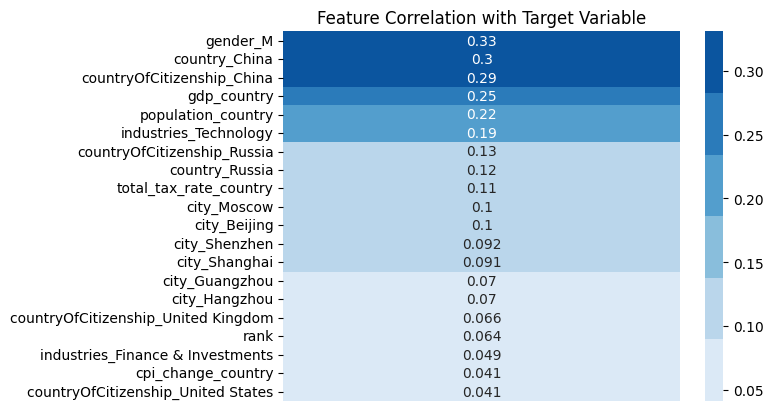

In [15]:
target_corr = pd.DataFrame(X.join(y).corrwith(y).sort_values(ascending=False))
sns.heatmap(target_corr.iloc[1:21], annot=True, xticklabels=False, cmap=sns.color_palette("Blues"))
plt.title("Feature Correlation with Target Variable")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print("Training set size: ", len(X_train))
print("Testing set size: ", len(X_test))

Training set size:  2112
Testing set size:  528


In [17]:
import shap
import xgboost as xgb

model = xgb.XGBClassifier().fit(X_train, y_train)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

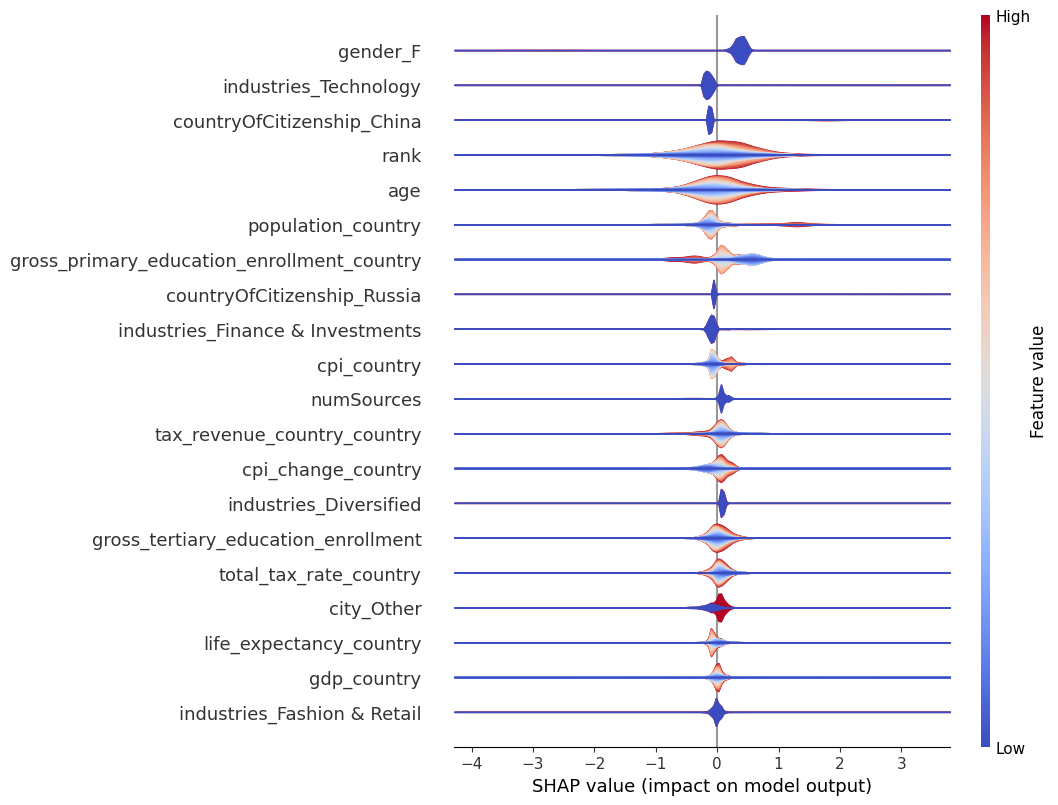

In [18]:
shap.plots.violin(shap_values, X_test, plot_type="layered_violin")

In [19]:
explainer = shap.TreeExplainer(model, data=X_train)
shap_values_train = explainer.shap_values(X_train)
shap_values_test = explainer.shap_values(X_test)

train_importance = np.abs(shap_values_train).mean(0)
test_importance = np.abs(shap_values_test).mean(0)

comparison_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_Train': train_importance,
    'Importance_Test': test_importance
}).sort_values(by='Importance_Test', ascending=False)

comparison_df['Diff_%'] = (np.abs(comparison_df['Importance_Train'] - comparison_df['Importance_Test']) / comparison_df['Importance_Train']) * 100

comparison_df.head(10)

,Feature,Importance_Train,Importance_Test,Diff_%
94,gender_F,0.775984,0.808223,4.154613
71,industries_Technology,0.517227,0.539427,4.292152
76,countryOfCitizenship_China,0.476092,0.513179,7.789826
0,rank,0.437850,0.428437,2.149645
11,population_country,0.392018,0.426824,8.878807
2,age,0.448536,0.418406,6.717525
7,gross_primary_education_enrollment_country,0.317100,0.316985,0.036311
86,countryOfCitizenship_Russia,0.238646,0.238718,0.030023
60,industries_Finance & Investments,0.189544,0.176254,7.011875
9,tax_revenue_country_country,0.160939,0.157311,2.254100


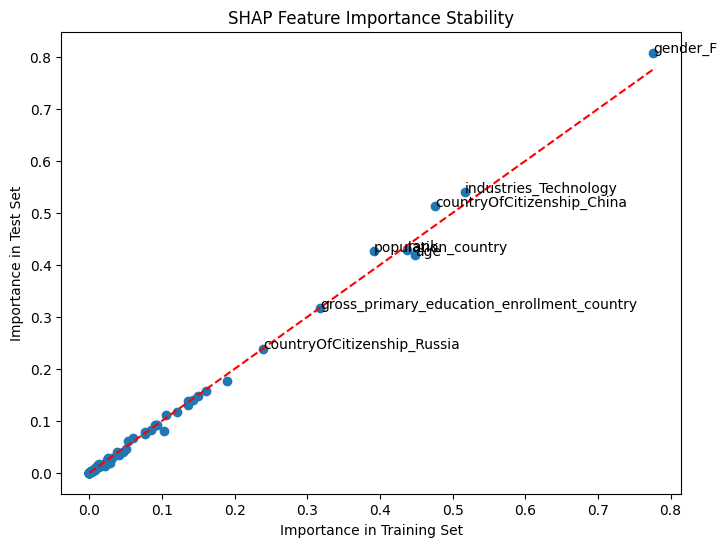

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(comparison_df['Importance_Train'], comparison_df['Importance_Test'])
plt.xlabel('Importance in Training Set')
plt.ylabel('Importance in Test Set')
plt.title('SHAP Feature Importance Stability')

# Add labels for the top features
for i, row in comparison_df.head(8).iterrows():
    plt.annotate(row['Feature'], (row['Importance_Train'], row['Importance_Test']))

# Add a 45-degree line (Perfect Stability)
plt.plot([0, max(train_importance)], [0, max(train_importance)], color='red', linestyle='--')
plt.show()